(np.float64(-0.5), np.float64(5182.5), np.float64(4475.5), np.float64(-0.5))

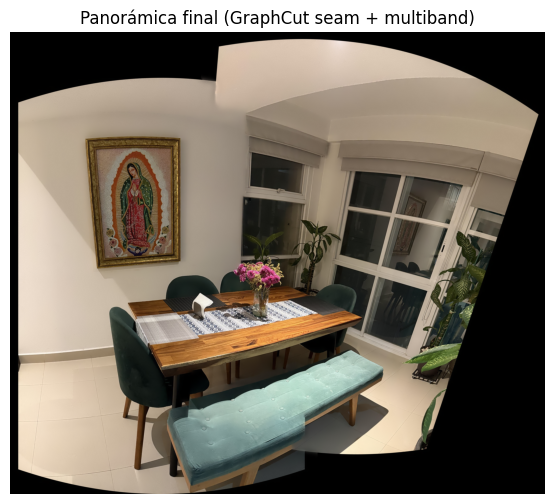

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

# ---------------------------
# Utilidades
# ---------------------------
def leer(ruta_base):
    # admite .jpg/.jpeg/.png
    for ext in (".jpg",".jpeg",".png",".JPG",".JPEG",".PNG"):
        p = ruta_base + ext
        if os.path.exists(p):
            img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
            return img, p
    raise FileNotFoundError(f"No encontré {ruta_base} con extensiones .jpg/.png")

def estimar_K_por_tamaño(img, f_ratio=0.7):
    h, w = img.shape[:2]
    f = f_ratio * max(h, w)
    cx, cy = w/2.0, h/2.0
    K = np.array([[f,0,cx],[0,f,cy],[0,0,1]], dtype=np.float32)
    return K

def warp_cilindrico(img, K):
    f, cx, cy = K[0,0], K[0,2], K[1,2]
    h, w = img.shape[:2]
    y_i, x_i = np.indices((h, w), dtype=np.float32)
    x = (x_i - cx)/f
    y = (y_i - cy)/f
    X, Y, Z = np.sin(x), y, np.cos(x)
    u = f*(X/Z) + cx
    v = f*(Y/Z) + cy
    warped = cv2.remap(img, u.astype(np.float32), v.astype(np.float32),
                       interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    return warped

def sift_match(img1g, img2g, ratio=0.7):
    sift = cv2.SIFT_create(nfeatures=4000, contrastThreshold=0.03, edgeThreshold=10)
    k1, d1 = sift.detectAndCompute(img1g, None)
    k2, d2 = sift.detectAndCompute(img2g, None)
    if d1 is None or d2 is None:
        raise RuntimeError("Sin descriptores. ¿Imagen muy lisa?")
    flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=64))
    m = flann.knnMatch(d1, d2, k=2)
    good = [a for a,b in m if a.distance < ratio*b.distance]
    pts1 = np.float32([k1[g.queryIdx].pt for g in good])
    pts2 = np.float32([k2[g.trainIdx].pt for g in good])
    return pts1, pts2

def homografia_ransac(pts1, pts2, thr=3.0, conf=0.999):
    H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC, ransacReprojThreshold=thr, confidence=conf)
    if H is None:
        raise RuntimeError("No se pudo estimar la homografía.")
    return H, mask

def preparar_lienzo(img1, img2, H):
    h1, w1 = img1.shape[:2]; h2, w2 = img2.shape[:2]
    c2 = np.float32([[0,0],[w2,0],[w2,h2],[0,h2]]).reshape(-1,1,2)
    wc2 = cv2.perspectiveTransform(c2, H)
    corners = np.vstack((wc2, np.float32([[0,0],[w1,0],[w1,h1],[0,h1]]).reshape(-1,1,2)))
    [xmin, ymin] = np.int32(corners.min(axis=0).ravel()) - 5
    [xmax, ymax] = np.int32(corners.max(axis=0).ravel()) + 5
    T = np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]], dtype=np.float32)
    size = (xmax - xmin, ymax - ymin)
    return T, size, (-xmin, -ymin)

# ---------------------------
# Blender de respaldo (feather)
# ---------------------------
def feather_blend(img1_c, img2_c, H):
    T, size, (ox, oy) = preparar_lienzo(img1_c, img2_c, H)
    w2 = cv2.warpPerspective(img2_c, T @ H, size)
    w1 = np.zeros_like(w2); h1, w1_img = img1_c.shape[:2]
    w1[oy:oy+h1, ox:ox+w1_img] = img1_c

    m1 = (w1.sum(axis=2) > 0).astype(np.float32)
    m2 = (w2.sum(axis=2) > 0).astype(np.float32)
    overlap = (m1 > 0) & (m2 > 0)

    pano = w1.copy().astype(np.float32)
    pano[~overlap & (m2 > 0)] = w2[~overlap & (m2 > 0)]

    if np.any(overlap):
        xs = np.where(overlap)[1]
        x_min, x_max = xs.min(), xs.max()
        alpha = np.zeros_like(m1)
        alpha[:, x_min:x_max+1] = np.linspace(1, 0, x_max-x_min+1)
        alpha = cv2.GaussianBlur(alpha, (51,51), 0)
        a3 = np.dstack([alpha]*3)
        pano[overlap] = a3[overlap]*w1[overlap] + (1-a3[overlap])*w2[overlap]

    return pano.astype(np.uint8)

# ---------------------------
# Blender pro: exposure + seam (GraphCut) + multiband
# ---------------------------
def detail_blend(img1_c, img2_c, H):
    # si no existe cv2.detail, caemos a feather
    if not hasattr(cv2, "detail_MultiBandBlender"):
        return feather_blend(img1_c, img2_c, H)

    T, size, (ox, oy) = preparar_lienzo(img1_c, img2_c, H)
    w2 = cv2.warpPerspective(img2_c, T @ H, size)
    w1 = np.zeros_like(w2); h1, w1_img = img1_c.shape[:2]
    w1[oy:oy+h1, ox:ox+w1_img] = img1_c

    # Máscaras base
    m1 = np.zeros((size[1], size[0]), np.uint8); m1[oy:oy+h1, ox:ox+w1_img] = 255
    m2 = cv2.warpPerspective(np.ones(img2_c.shape[:2], np.uint8)*255, T @ H, size)

    # 1) exposure compensation (ganancia por bloques)
    try:
        compensator = cv2.detail_ExposureCompensator_createDefault(cv2.detail.ExposureCompensator_GAIN_BLOCKS)
        compensator.feed([np.array([0,0], np.int32), np.array([0,0], np.int32)],
                         [w1.astype(np.int16), w2.astype(np.int16)],
                         [m1, m2])
        compensator.apply(0, np.array([0,0]), w1, m1)
        compensator.apply(1, np.array([0,0]), w2, m2)
    except Exception:
        pass  # si falla, seguimos sin compensación

    # 2) seam finder (GraphCut) para elegir línea de empalme
    try:
        seam_finder = cv2.detail_GraphCutSeamFinder("COST_COLOR")
        masks = [m1.copy(), m2.copy()]
        images = [w1.astype(np.float32), w2.astype(np.float32)]
        corners = [np.array([0,0], np.int32), np.array([0,0], np.int32)]
        masks = seam_finder.find(images, corners, masks)
        m1s, m2s = masks
        if isinstance(m1s, cv2.UMat): m1s = m1s.get()
        if isinstance(m2s, cv2.UMat): m2s = m2s.get()
    except Exception:
        m1s, m2s = m1, m2  # respaldo

    # 3) multiband blender
    blender = cv2.detail_MultiBandBlender()
    blender.setNumBands(5)   # 3–7 según textura
    blender.prepare(np.array([0,0, size[0], size[1]]))

    blender.feed(w1.astype(np.int16), m1s, np.array([0,0]))
    blender.feed(w2.astype(np.int16), m2s, np.array([0,0]))
    result, result_mask = blender.blend(None, None)
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result

# ---------------------------
# Pipeline completo con IMG01 / IMG02
# ---------------------------
ruta1_base, ruta2_base = "IMG01", "IMG02"
img1, p1 = leer(ruta1_base)
img2, p2 = leer(ruta2_base)

# K por tamaño de imagen (ajustable f_ratio si quieres más/menos curvatura)
K = estimar_K_por_tamaño(img1, f_ratio=0.7)

img1_c = warp_cilindrico(img1, K)
img2_c = warp_cilindrico(img2, K)

g1, g2 = cv2.cvtColor(img1_c, cv2.COLOR_RGB2GRAY), cv2.cvtColor(img2_c, cv2.COLOR_RGB2GRAY)
pts1, pts2 = sift_match(g1, g2, ratio=0.7)
H, _ = homografia_ransac(pts1, pts2, thr=3.0, conf=0.999)

# Mezcla pro (con respaldo feather)
pano = detail_blend(img1_c, img2_c, H)

# Recorte automático del área válida
gray = cv2.cvtColor(pano, cv2.COLOR_RGB2GRAY)
mask = (gray > 0).astype(np.uint8)*255
x,y,w,h = cv2.boundingRect(mask)
pano_crop = pano[y:y+h, x:x+w]

plt.figure(figsize=(14,6))
plt.imshow(pano_crop)
plt.title("Panorámica final (GraphCut seam + multiband)")
plt.axis('off')
